## Missing Data Analysis (Binance UM Futures)

During the data validation phase for `SOLUSDT` (1-minute intervals, 2021-2026), DuckDB detected exactly 7,200 missing continuous timestamps (which equates to exactly 5 full days of missing data). 

**Root Cause:** 
This is a known behavior of the Binance historical data archives. During major exchange maintenance or periods of extreme market volatility, the matching engine for specific pairs is temporarily halted, resulting in missing kline (OHLCV) records.

**Resolution:**
To maintain a strictly continuous time-series index (which is absolutely critical for constructing fixed-size lookback windows in our PyTorch GRU without look-ahead bias), we must dynamically inject these missing minutes into the dataset during the DuckDB ETL phase. 
Missing prices will be forward-filled (`ffill`) from the last known `close` price, and all volumetric features (trading volume, number of trades, quote asset volume) will be set to `0`. This mathematically simulates holding a position during an exchange halt.

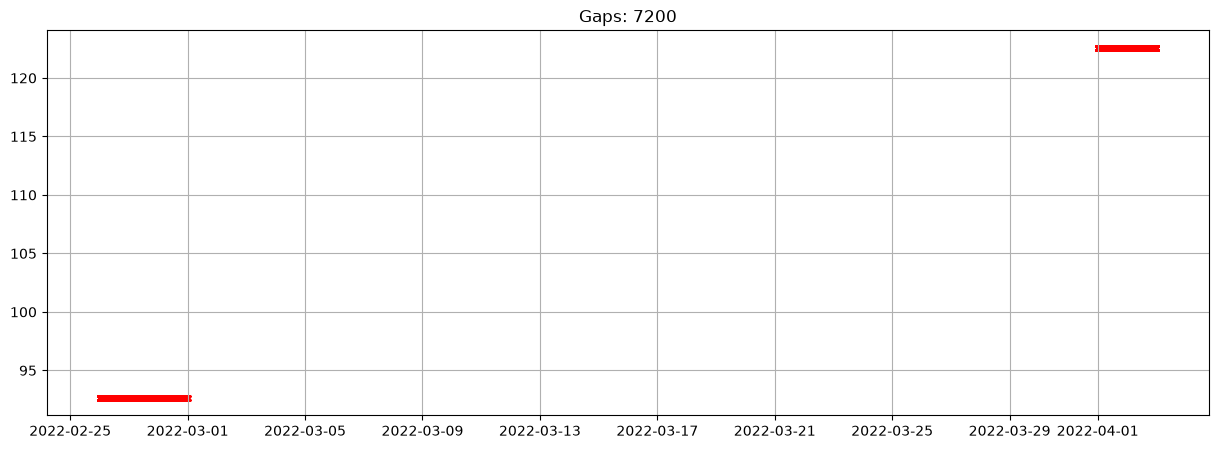

In [1]:
import pandas as pd
from matplotlib import pyplot as plt

parquet_path = '../data/processed/SOLUSDT_2021_2026.parquet'

index = pd.date_range('2021-07-01 00:00', '2026-07-01 00:00', freq='min', inclusive='left')
df = pd.read_parquet('../data/processed/SOLUSDT_2021_2026.parquet', columns=['open_time', 'open'])
df.set_index('open_time', inplace=True)
gap_idx = index.difference(df.index)
n_gaps = len(gap_idx)

plt.figure(figsize=(15, 5))
plt.scatter(gap_idx, df['open'].reindex(index).ffill().bfill().loc[gap_idx], 15, 'r', marker='x')
plt.title(f'Gaps: {n_gaps}')
plt.grid()
plt.show()

In [2]:
import duckdb

conn = duckdb.connect()

conn.execute(f"""
  CREATE TEMP TABLE raw_data AS 
  SELECT *
  FROM read_parquet('{parquet_path}')
""")

conn.execute(f"""
  COPY (
    WITH expected_index AS (
      SELECT unnest(generate_series(
        TIMESTAMP '2021-07-01 00:00:00', 
        TIMESTAMP '2026-07-01 00:00:00' - INTERVAL 1 MINUTE, 
        INTERVAL 1 MINUTE
      )) AS open_time
    ),
    joined AS (
      SELECT 
        t.open_time,
        r.open, r.high, r.low, r.close,
        COALESCE(r.volume, 0) AS volume,
        COALESCE(r.qav, 0) AS qav,
        COALESCE(r.n_trades, 0) AS n_trades,
        COALESCE(r.buy_volume, 0) AS buy_volume,
        COALESCE(r.buy_qav, 0) AS buy_qav
      FROM expected_index t
      LEFT JOIN raw_data r ON t.open_time = r.open_time
    ),
    filled AS (
      SELECT
        open_time,
        volume, qav, n_trades, buy_volume, buy_qav,
        open, high, low, close,
        last_value(close IGNORE NULLS) OVER (ORDER BY open_time) AS ffill_close
      FROM joined
    )
    SELECT 
      open_time,
      COALESCE(open, ffill_close) AS open,
      COALESCE(high, ffill_close) AS high,
      COALESCE(low, ffill_close) AS low,
      COALESCE(close, ffill_close) AS close,
      volume, qav, n_trades, buy_volume, buy_qav
    FROM filled
    ORDER BY open_time
  ) TO '{parquet_path}' (FORMAT PARQUET)
""")

conn.close()